# Introduction

By completing this card, you will be able to:

1. Understand the intuition behind decision tree;
2. Implement the algorithm of decision tree;
3. Understand the important metrics (gini impurity, entropy) that involved in the process of decision tree construction;
4. Know how to evaluate the performance of the decision tree model and the importance of input features;

A decision tree for classification is a special form of binary tree, which is used as a classifier. There are two types of nodes in decision tree:

- leaf node: same as the ones in binary tree, i.e. the node that does not have any child node. 
- decision node: the non-leaf node.

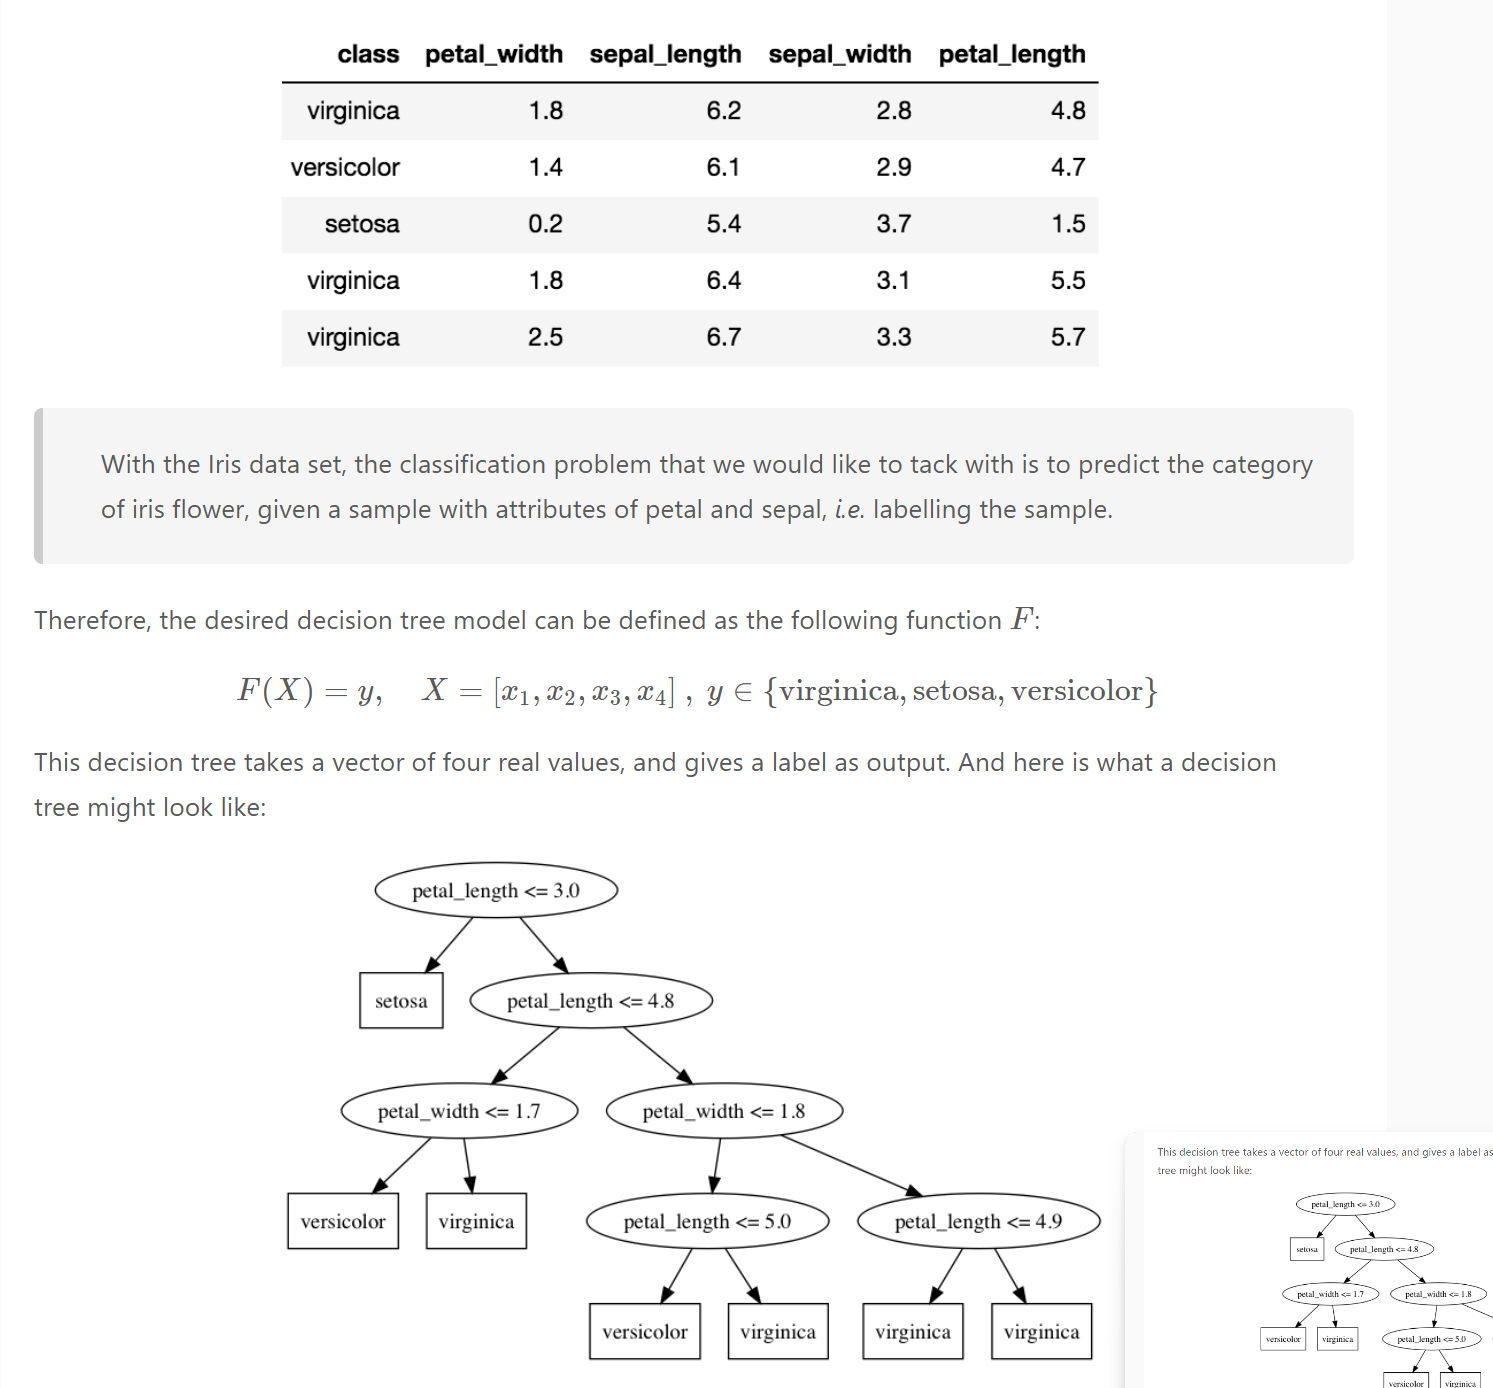

# Gini Impurity


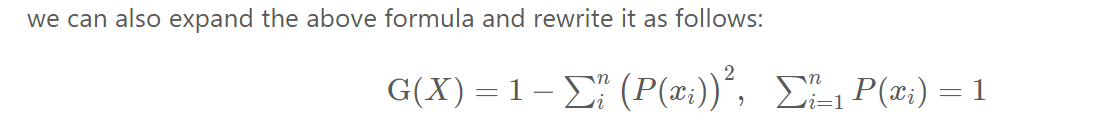

# 一、什么是 Gini Impurity（基尼不纯度）

## 1. 直观理解

Gini Impurity 衡量的是：

👉 **一个节点中的数据“有多混乱”**

* 如果一个节点里全是同一类 → 非常纯 → impurity = 0
* 如果类别混在一起 → 很混乱 → impurity 高

你可以理解为：

> 随机抽一个样本，再随机按当前分布猜类别，猜错的概率是多少？

---

## 2. 数学定义

对于一个节点，有 (K) 个类别，每个类别概率为 (p_i)，则：

Gini = 1 - \sum_{i=1}^{K} p_i^2

---

## 3. 举个具体例子

假设一个节点里有 10 个样本：

* 7 个是正类（+）
* 3 个是负类（-）

那么：

[
p_+ = 0.7,\quad p_- = 0.3
]

计算：

[
Gini = 1 - (0.7^2 + 0.3^2) = 1 - (0.49 + 0.09) = 0.42
]

👉 说明：这个节点“有点混乱”

---

## 4. 特殊情况

* 完全纯：
  [
  Gini = 0
  ]

* 完全均匀（二分类）：
  [
  p=0.5 \Rightarrow Gini = 0.5
  ]

👉 这是最“乱”的情况

---

# 二、什么是 Gini Gain（基尼增益）

## 1. 直观理解

Gini Gain 衡量的是：

👉 **一次划分让数据“变得更纯了多少”**

也就是：

> 分裂前的混乱程度 - 分裂后的混乱程度

---

## 2. 数学定义

设：

* 父节点 impurity：(G_{parent})
* 分裂成左右子节点：

  * 左：(G_L)，样本数 (N_L)
  * 右：(G_R)，样本数 (N_R)

则：

$$
Gini\ Gain = G_{parent} - \left( \frac{N_L}{N} G_L + \frac{N_R}{N} G_R \right)
$$

---

## 3. 举个完整计算例子

### Step 1：父节点

10 个样本：

* 7 正
* 3 负

$$
G_{parent} = 0.42
$$

---

### Step 2：分裂后

假设某个特征把数据分成：

#### 左节点（6个）：

* 6 正，0 负
  $$
  G_L = 0
$$

#### 右节点（4个）：

* 1 正，3 负
  [
  p_+ = 0.25,\ p_- = 0.75
  ]
  [
  G_R = 1 - (0.25^2 + 0.75^2) = 0.375
  ]

---

### Step 3：加权平均

[
G_{split} = \frac{6}{10} \cdot 0 + \frac{4}{10} \cdot 0.375 = 0.15
]

---

### Step 4：计算 Gini Gain

[
Gini\ Gain = 0.42 - 0.15 = 0.27
]

---

## 4. 解释结果

👉 Gini Gain = 0.27 表示：

* 这次分裂 **显著提升了纯度**
* 是一个“好的划分”

---

# 三、总结（核心区别）

| 概念            | 含义       | 用途     |
| ------------- | -------- | ------ |
| Gini Impurity | 当前节点有多乱  | 衡量节点质量 |
| Gini Gain     | 分裂带来多少改善 | 选择最优分裂 |

---

# 四、和 Entropy 的关系（补充）

另一个常见指标是 Information Gain：

* Gini：计算简单（平方）
* Entropy：信息论解释更强（对数）

👉 实际中：

* Scikit-learn 默认用 **Gini**
* 因为：更快，效果差不多

---

如果你愿意，我可以帮你做一个**可视化（画决策树如何选择split）**，或者写一段 **PyTorch / sklearn代码**带你从数据算一遍，这样你会更扎实理解。
